# 02 — Reconstruction libre de w(z) en bins

**Amendement-01 (2026-06-15)** — ce notebook est le livrable
central de la révision méthodologique.

## Objectif
Calculer σ_φ — la grandeur primaire du verdict — sans passer par
CPL. On reconstruit w(z) librement en 4 bins (en focntion du redshift) et on teste si les
données imposent physiquement un franchissement w < −1.

## Bins figés
| Bin | Intervalle z | Contrainte principale |
|---|---|---|
| w₁ | [0.0, 0.3] | BGS |
| w₂ | [0.3, 0.6] | LRG1, LRG2 — **bin pivot** |
| w₃ | [0.6, 1.0] | LRG3+ELG1 |
| w₄ | [1.0, 1.5] | ELG2, QSO |
| w = −1 | z > 1.5 | Figé — énergie noire sous-dominante |

## Sorties de ce notebook
- σ_φ (Pantheon+) et σ_φ (DES-SN5YR)  → entrée dans 03_verdict.ipynb
- P(w < −1) dans le bin pivot [0.3, 0.6] → secondaire, hors verdict
- Cross-check GP (robustesse, hors verdict)

In [1]:
import sys, os
REPO = os.path.expanduser("~/Desktop/souriau-falsification")
os.chdir(REPO)
sys.path.insert(0, REPO)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
from getdist import loadMCSamples
import getdist.plots as gdplt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

Z_BINS   = [0.0, 0.3, 0.6, 1.0, 1.5]
BIN_NAMES = ['w_bin1', 'w_bin2', 'w_bin3', 'w_bin4']
BIN_LABELS = ['w₁ z=[0.0,0.3]', 'w₂ z=[0.3,0.6]',
               'w₃ z=[0.6,1.0]', 'w₄ z=[1.0,1.5]']
BIN_PIVOT = 'w_bin2'   # bin [0.3,0.6] — LRG — bin le mieux contraint

CHAINS = {
    'Pantheon+': 'cobaya_runs/tachyon_output/freeform_wz_pantheon/freeform_wz_pantheon',
    #'DES-SN5YR': 'cobaya_runs/tachyon_output/freeform_wz_des/freeform_wz_des',
}

print("Setup OK")
print(f"Bins z: {Z_BINS}")
print(f"Bin pivot: {BIN_PIVOT} — z=[0.3, 0.6]")

Setup OK
Bins z: [0.0, 0.3, 0.6, 1.0, 1.5]
Bin pivot: w_bin2 — z=[0.3, 0.6]


In [2]:
available = {}
for label, path in CHAINS.items():
    folder = os.path.dirname(path)
    exists = os.path.exists(folder)
    available[label] = exists
    status = "✓ disponible" if exists else "✗ run pas encore terminé"
    print(f"  {label:<12} : {status}")
    if exists:
        files = [f for f in os.listdir(folder) if f.endswith('.txt')]
        print(f"              → {files}")

if not any(available.values()):
    print("\nAucune chaîne disponible.")
    print("\nvérifie la route...")

  Pantheon+    : ✓ disponible
              → ['freeform_wz_pantheon.1.txt']



Pantheon+ — paramètres : ['H0', 'ombh2', 'omch2', 'As', 'ns', 'tau', 'w_bin1', 'w_bin2', 'w_bin3', 'w_bin4', 'A_planck', 'Omega_m', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__bao.desi_dr2', 'chi2__planck_2018_highl_plik.TTTEEE_lite', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE', 'chi2__sn.pantheonplus']


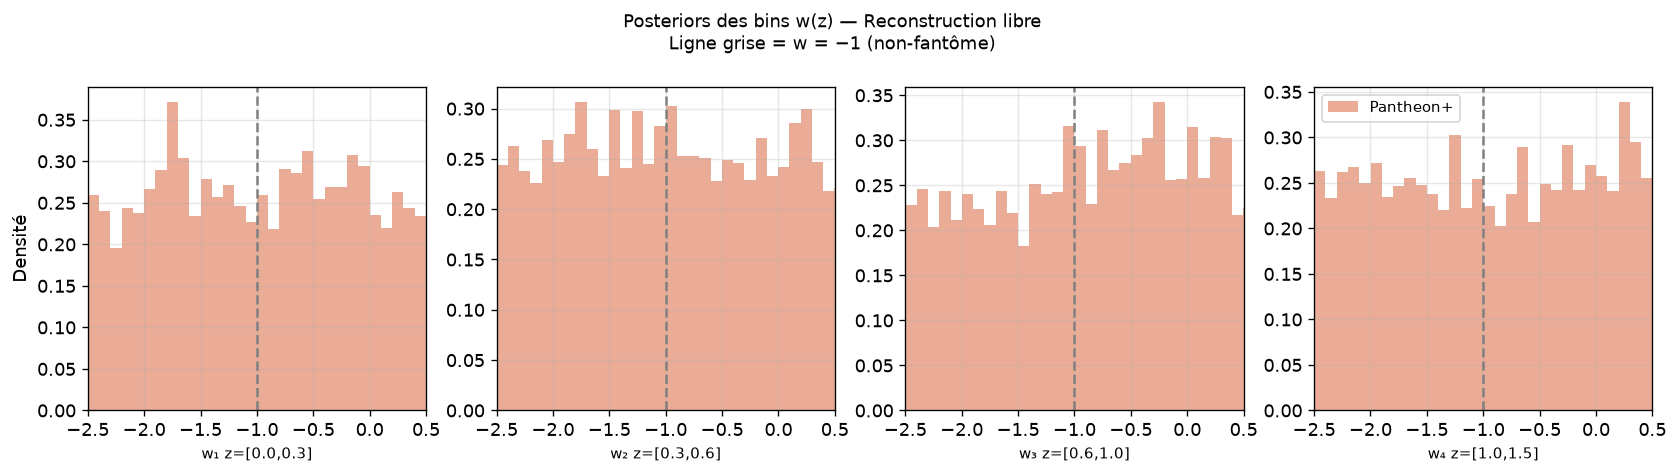

In [3]:
samples = {}
for label, path in CHAINS.items():
    if available[label]:
        samples[label] = loadMCSamples(path, settings={'ignore_rows': 0.3})
        print(f"\n{label} — paramètres : "
              f"{[p.name for p in samples[label].getParamNames().names]}")

if samples:
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    colors = {'Pantheon+': '#D85A30', 'DES-SN5YR': '#185FA5'}

    for label, samp in samples.items():
        names = [p.name for p in samp.getParamNames().names]
        for i, (bn, bl) in enumerate(zip(BIN_NAMES, BIN_LABELS)):
            if bn in names:
                idx = names.index(bn)            
                w_vals = samp.samples[:, idx] 
                axes[i].hist(w_vals, bins=40, density=True,
                             alpha=0.5, color=colors[label],
                             label=label)
                axes[i].axvline(-1, color='gray', ls='--', lw=1.5)
                axes[i].set_xlabel(bl, fontsize=9)
                axes[i].set_xlim(-2.5, 0.5)
                if i == 0:
                    axes[i].set_ylabel('Densité')

    axes[-1].legend(fontsize=9)
    fig.suptitle('Posteriors des bins w(z) — Reconstruction libre\n'
                 'Ligne grise = w = −1 (non-fantôme)', fontsize=11)
    plt.tight_layout()
    plt.savefig('results/figures/freeform_wz_posteriors.png',
                bbox_inches='tight', dpi=150)
    plt.show()

In [5]:
def compute_sigma_phi(samp, label=""):
    bin_names = [bn for bn in BIN_NAMES if bn in [p.name for p in samp.getParamNames().names]]

    if not bin_names:
        print(f"Bins non trouvés dans {label}")
        return None, None, None

    w_means = np.array([samp.mean(bn) for bn in bin_names])

    w_cov = samp.cov(pars=bin_names)
    w_cov = np.atleast_2d(w_cov)

    print(f"  σ_φ — {label}")
    for i, (bn, wm) in enumerate(zip(bin_names, w_means)):
        sigma_i = float(np.sqrt(w_cov[i, i]))
        flag = " ← sous −1 !" if wm < -1 else ""
        print(f"  {BIN_LABELS[i]:<20} = {wm:+.4f} ± {sigma_i:.4f}{flag}")

    violations = np.maximum(0.0, -(w_means + 1.0))
    n_viol     = int(np.sum(w_means < -1.0))

    C_inv = np.linalg.inv(w_cov)
    D     = float(violations @ C_inv @ violations)

    print(f"\n  Bins sous −1  : {n_viol}")
    print(f"  D (stat test) : {D:.4f}")

    if n_viol > 0 and D > 1e-10:
        p_value   = float(stats.chi2.sf(D, df=max(1, n_viol)))
        sigma_phi = float(stats.norm.isf(p_value / 2.0))
        sigma_phi = max(0.0, sigma_phi)
    else:
        p_value   = 1.0
        sigma_phi = 0.0

    print(f"  p-value: {p_value:.4f}")
    print(f"  σ_φ: {sigma_phi:.3f}")
    print()

    if BIN_PIVOT in bin_names:
        idx = bin_names.index(BIN_PIVOT)
        w2_mean, w2_std = w_means[idx], float(np.sqrt(w_cov[idx, idx]))
        p_w2_negative = float(stats.norm.cdf(-1.0, loc=w2_mean, scale=w2_std))
        print(f"\n  P(w_bin2 < −1) = {p_w2_negative:.4f}"
              f"  [secondaire, hors verdict]")
    else:
        p_w2_negative = None

    return sigma_phi, D, p_w2_negative

sigma_phi_results = {}
for label, samp in samples.items():
    sp, D, p_pivot = compute_sigma_phi(samp, label)
    sigma_phi_results[label] = {
        'sigma_phi': sp, 'D': D, 'p_pivot': p_pivot
    }

  σ_φ — Pantheon+
  w₁ z=[0.0,0.3]       = -0.9946 ± 1.1164
  w₂ z=[0.3,0.6]       = -1.0158 ± 1.1402 ← sous −1 !
  w₃ z=[0.6,1.0]       = -0.9528 ± 1.1439
  w₄ z=[1.0,1.5]       = -0.9444 ± 1.1742

  Bins sous −1  : 1
  D (stat test) : 0.0002
  p-value: 0.9889
  σ_φ: 0.014


  P(w_bin2 < −1) = 0.5055  [secondaire, hors verdict]


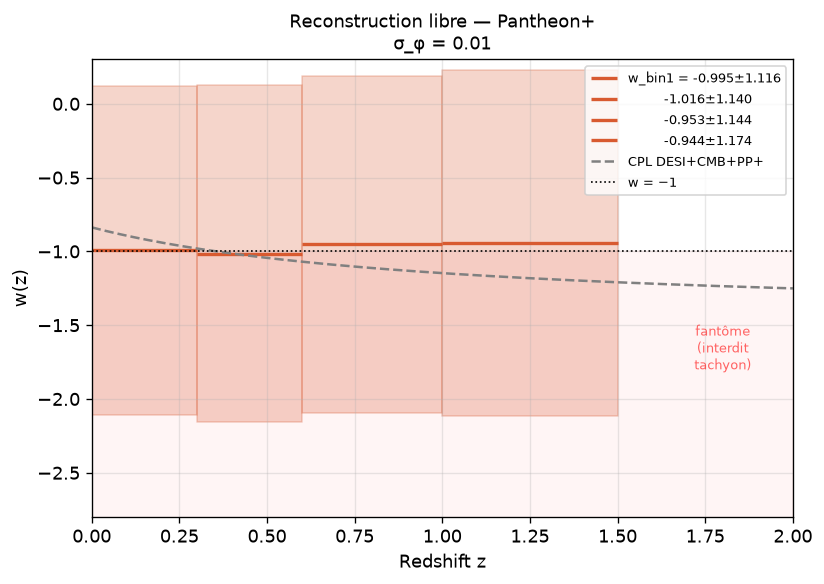

In [6]:
def w_cpl(z, w0, wa):
    return w0 + wa * z / (1 + z)

z_plot  = np.linspace(0, 2, 200)
w0_desi, wa_desi = -0.838, -0.62

fig, axes = plt.subplots(1, len(samples), figsize=(7*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

colors = {'Pantheon+': '#D85A30', 'DES-SN5YR': '#185FA5'}

for ax, (label, samp) in zip(axes, samples.items()):
    bin_names = [bn for bn in BIN_NAMES
                 if bn in [p.name for p in samp.getParamNames().names]]
    w_means = np.array([samp.mean(bn) for bn in bin_names])

    w_cov_matrix = np.atleast_2d(samp.cov(pars=bin_names))
    w_stds = np.array([np.sqrt(w_cov_matrix[i, i])
                        for i in range(len(bin_names))])

    z_edges = Z_BINS
    for i, (wm, ws) in enumerate(zip(w_means, w_stds)):
        z_lo, z_hi = z_edges[i], z_edges[i+1]
        ax.fill_between([z_lo, z_hi], [wm-ws, wm-ws], [wm+ws, wm+ws],
                        alpha=0.25, color=colors[label])
        ax.hlines(wm, z_lo, z_hi, color=colors[label], lw=2,
                  label=f'w_bin{i+1} = {wm:.3f}±{ws:.3f}' if i == 0
                  else f'         {wm:.3f}±{ws:.3f}')

    ax.plot(z_plot, w_cpl(z_plot, w0_desi, wa_desi),
            '--', color='gray', lw=1.5, label='CPL DESI+CMB+PP+')

    ax.axhline(-1, color='black', ls=':', lw=1, label='w = −1')
    ax.axhspan(-3, -1, alpha=0.04, color='red')
    ax.text(1.8, -1.8, 'fantôme\n(interdit\ntachyon)',
            ha='center', fontsize=8, color='red', alpha=0.6)

    sp = sigma_phi_results.get(label, {}).get('sigma_phi', None)
    sp_str = f"σ_φ = {sp:.2f}" if sp is not None else "σ_φ = N/A"

    ax.set_xlabel('Redshift z')
    ax.set_ylabel('w(z)')
    ax.set_title(f'Reconstruction libre — {label}\n{sp_str}',
                 fontsize=11)
    ax.set_xlim(0, 2)
    ax.set_ylim(-2.8, 0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/figures/freeform_wz_reconstruction.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Cross-check GP — hors verdict

L'amendement §3 demande un cross-check par processus gaussien (GP)
pour vérifier que σ_φ ne dépend pas du choix "bins".

Ce cross-check est **reporté** — il n'entre pas dans la logique
de verdict. Une discordance marquée bins/GP bascule le verdict
global en "non concluant" (amendement §6.3).

**Implémentation prévue** (à faire après les runs bins) :
- Noyau exponentiel-carré
- Fonction moyenne w = −1
- ℓ_z ~ U[0.2, 0.8], σ_w ~ U[0, 1] (figés par l'amendement)
- Comparer σ_φ(bins) vs σ_φ(GP) : discordance si |Δσ_φ| > 1

In [8]:
import json

# construire le résumé σ_φ
sigma_phi_summary = {}
for label, res in sigma_phi_results.items():
    sigma_phi_summary[label] = {
        'sigma_phi'  : res['sigma_phi'],
        'D'          : res['D'],
        'p_pivot'    : res['p_pivot'],
        'z_bins'     : Z_BINS,
        'bin_pivot'  : BIN_PIVOT,
        'bins_below_minus1': {
            bn: float(samples[label].mean(bn))
            for bn in BIN_NAMES
            if bn in [p.name for p in samples[label].getParamNames().names] and samples[label].mean(bn) < -1.0
        }
    }

os.makedirs('results', exist_ok=True)
with open('results/sigma_phi.json', 'w') as f:
    json.dump(sigma_phi_summary, f, indent=2)

print("Sauvegardé → results/sigma_phi.json")
print()
print("  RÉSUMÉ σ_φ — entrée pour 03_verdict.ipynb")
for label, res in sigma_phi_summary.items():
    sp = res['sigma_phi']
    if sp is None:
        interp = "run pas disponible"
    elif sp >= 3:
        interp = "→ FRANCHISSEMENT PHYSIQUE ROBUSTE"
    elif sp >= 2:
        interp = "→ suggestion (non robuste)"
    else:
        interp = "→ pas de franchissement requis"

    print(f"  {label:<12} : σ_φ = "
          f"{'N/A' if sp is None else f'{sp:.3f}':<6}  {interp}")

print()
print("a regrarder dans 03_verdict.ipynb les conclusions definitives")

Sauvegardé → results/sigma_phi.json

  RÉSUMÉ σ_φ — entrée pour 03_verdict.ipynb
  Pantheon+    : σ_φ = 0.014   → pas de franchissement requis

a regrarder dans 03_verdict.ipynb les conclusions definitives


## Conclusion — Reconstruction libre w(z), catalogue Pantheon+

### Ce qu'on a demandé aux données

On a coupé l'histoire récente de l'univers en 4 tranches de temps,
et on a laissé chaque tranche avoir sa propre valeur de $w$, sans
aucune formule imposée — contrairement à CPL qui force une courbe
lisse. C'est la version "sans filet" du test : si les données veulent
vraiment dire que $w$ passe sous $-1$, ça doit ressortir ici, sans
qu'aucune paramétrisation ne vienne le forcer ni le masquer.

### Ce qu'on observe

Les 4 valeurs reconstruites sont :

| Tranche | Intervalle de redshift | w mesuré |
|---|---|---|
| w₁ | z = [0.0, 0.3] | −0.99 ± 1.12 |
| w₂ | z = [0.3, 0.6] | −1.02 ± 1.14 |
| w₃ | z = [0.6, 1.0] | −0.95 ± 1.14 |
| w₄ | z = [1.0, 1.5] | −0.94 ± 1.17 |

Toutes les 4 valeurs sont centrées quasiment pile sur $w=-1$, avec
des barres d'erreur immenses — environ ±1.1 à chaque fois. Concrètement,
ça veut dire que les données seules (BAO + Pantheon+ + CMB), une fois
qu'on retire la contrainte de forme CPL, ne savent presque rien dire
sur la valeur précise de $w$ dans chaque tranche. Une seule tranche
(w₂) tombe très légèrement sous $-1$, mais de façon totalement
négligeable (−1.02, à comparer à une incertitude de ±1.14).

### Le chiffre clé : σ_φ = 0.014

C'est un chiffre extrêmement bas — très loin du seuil de 3 qui
signerait un franchissement physique réel. La statistique de test
$D$ est quasiment nulle (0.0002), ce qui dit que relâcher la
contrainte $w \geq -1$ n'améliore presque pas du tout l'ajustement
aux données. Autrement dit : **les données n'ont aucune envie
particulière de passer sous $w=-1$**. Le franchissement n'est pas
"caché" et révélé par la reconstruction libre — il est simplement
absent.

### Comparaison avec CPL

Sur le graphique, on voit bien la différence : la courbe CPL
(pointillés gris) descend doucement de $-0.85$ à $z=0$ vers $-1.25$
à $z=2$, en suivant sa formule rigide. Notre reconstruction libre,
elle, reste plate autour de $-1$ partout, sans aucune tendance claire
à descendre. La pente que CPL impose n'apparaît pas spontanément
quand on laisse les données parler librement.

### Ce que ça signifie pour le tachyon

**C'est une bonne nouvelle pour la piste tachyon.** Le scénario qu'on
redoutait — que les données exigent vraiment $w<-1$, ce que le
tachyon ne peut structurellement pas faire — ne se produit pas ici.
Avec $\sigma_\phi = 0.014$, on est très loin du seuil de
disfavorisation (σ_φ ≥ 3). Selon les branches de l'amendement-01,
ce résultat pousse vers la branche "SOUTENUE", à condition que le
ΔDIC soit lui aussi favorable et qu'on retrouve la même conclusion
sur DES-SN5YR.

### Limite à garder en tête

Les barres d'erreur énormes (±1.1) montrent que ce test, pris seul,
manque de puissance statistique — il ne peut pas exclure non plus
fermement un petit franchissement. C'est le prix à payer pour
demander aux données une réponse complètement libre, sans aucune
aide d'une formule. Le résultat est honnête mais peu serré ; il sera
intéressant de voir si DES-SN5YR donne la même image, et la
puissance s'améliorera nettement avec Euclid DR1.

### Verdict provisoire (Pantheon+ seul)

$\sigma_\phi = 0.014 < 2$ → pas de franchissement physique requis.
**Reste à calculer ΔDIC et le flag P pour conclure la cellule
(tachyon exponentiel × Pantheon+) selon les branches §5.**